## 1.Python-Generator zum Laden von Bildern

In [7]:
import os
import cv2
import sqlite3
import numpy as np
from PIL import Image
import pandas as pd
from skimage.feature import local_binary_pattern
from skimage.measure import shannon_entropy
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
import pickle
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from scipy.sparse import dok_matrix
from tqdm import tqdm
from joblib import Parallel, delayed
import ast


In [10]:
def image_generator(folder_path):
    image_id = 0
    
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        yield image_id, file_path
        image_id += 1

folder_path = "/Volumes/BigData03/images/coco2017_unlabeled/unlabeled2017"
generator = image_generator(folder_path)



## 2. Verwendung einer Datenbank für die Bildverwaltung und Metadaten extrahieren

In [14]:
def extract_basic_metadata(image_folder):
    metadata_list = []
    
    for file_name in os.listdir(image_folder):
        file_path = os.path.join(image_folder, file_name)
        
        # Überprüfen, ob die Datei eine Bilddatei ist
        if is_valid_image(file_path):
            
            try:
                image = Image.open(file_path)
                
                # Extrahieren der grundlegenden Metadaten
                file_name = os.path.basename(file_path)
                file_size = os.path.getsize(file_path)
                image_format = image.format
                image_width, image_height = image.size
                
                
                
                # Ein Metadaten-Dictionary erstellen und zur Liste hinzufügen
                metadata = {
                    'file_name': file_name,
                    'file_size': file_size,
                    'image_format': image_format,
                    'image_width': image_width,
                    'image_height': image_height,
                }
                metadata_list.append(metadata)
                
                
                image.close()
                
            except IOError:
                print(f"Fehler beim Öffnen des Bildes: {file_path}")
    
    return metadata_list

def is_valid_image(file_path):
    supported_extensions = ['.jpg', '.jpeg', '.png', '.gif']
    file_extension = os.path.splitext(file_path)[1].lower()
    return file_extension in supported_extensions


image_folder = "/Volumes/BigData03/images/coco2017_unlabeled/unlabeled2017"

# Metadaten aus allen Bildern im Ordner extrahieren
metadata_list = extract_basic_metadata(image_folder)


In [12]:
def create_database(database_path):
    conn = sqlite3.connect(database_path)
    c = conn.cursor()

    c.execute('''CREATE TABLE IF NOT EXISTS images
                 (id INTEGER PRIMARY KEY AUTOINCREMENT, file_name TEXT, location TEXT, file_path TEXT)''')

    conn.commit()
    conn.close()

def insert_image_data(database_path, file_name, location, file_path):
    conn = sqlite3.connect(database_path)
    c = conn.cursor()

    c.execute("INSERT INTO images (file_name, location, file_path) VALUES (?, ?, ?)",
              (file_name, location, file_path))

    conn.commit()
    conn.close()

database_path = "/Users/shadobanbouk/Desktop/new_image_database.db"
create_database(database_path)

folder_path = "/Volumes/BigData03/images/coco2017_unlabeled/unlabeled2017"
generator = image_generator(folder_path)

def is_valid_image(file_path):
    supported_extensions = ['.jpg', '.jpeg', '.png', '.gif']
    file_extension = os.path.splitext(file_path)[1].lower()
    return file_extension in supported_extensions

for image_id, file_path in generator:
    if is_valid_image(file_path):
        file_name = os.path.basename(file_path)
        location = os.path.dirname(file_path)

        insert_image_data(database_path, file_name, location, file_path)


## Sicher stellen dass die Daten erfolgreich in der Datenbank gespeichert wurden 

In [163]:
def retrieve_image(database_path, image_id):
    conn = sqlite3.connect(database_path)
    c = conn.cursor()

    c.execute("SELECT * FROM images WHERE id=?", (image_id,))
    row = c.fetchone()

    conn.close()

    return row

database_path = "/Users/shadobanbouk/Desktop/image_database.db"
image_id = 10
image = retrieve_image(database_path, image_id)

if image:
    image_id, file_name, location, metadata, additional_info = image
    print(f"Image ID: {image_id}, File Name: {file_name}, Location: {location}, Metadata: {metadata}, Additional Info: {additional_info}")
else:
    print(f"Image with ID {image_id} not found in the database.")


Image ID: 10, File Name: 2048.jpg, Location: /Users/shadobanbouk/Desktop/weather_image_recognition/lightning, Metadata: {'file_name': '2048.jpg', 'file_size': 43084, 'image_format': 'JPEG', 'image_width': 400, 'image_height': 283}, Additional Info: None


# 3.Bildähnlichkeit:

## 3.1 - Color Profile Similarity 

In [15]:
def calculate_color_profile(image):
    # Farbhistogramm berechnen
    hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    hist /= hist.sum()

    return hist.flatten()

def calculate_color_profile_similarity(query_hist, hist):
    # Bhattacharyya-Distanz berechnen
    similarity = cv2.compareHist(query_hist, hist, cv2.HISTCMP_BHATTACHARYYA)

    # Ähnlichkeit basierend auf der Distanz berechnen
    similarity = 1 - similarity

    return similarity

In [26]:
def calculate_color_profiles(image_folder):
    # DataFrame für Bildinformationen erstellen
    columns = ['Image ID', 'File Path', 'Color Profile']
    image_data = pd.DataFrame(columns=columns)

    # Bilder aus dem Hauptordner durchgehen
    color_profiles = []
    for file_name in os.listdir(image_folder):
        if file_name.endswith('.DS_Store'):
            continue

        file_path = os.path.join(image_folder, file_name)
        image = cv2.imread(file_path)
        if image is None:
            print(f"Fehler beim Laden des Bildes: {file_path}")
            continue

        hist = calculate_color_profile(image)
        color_profiles.append(hist)

    # DataFrame mit den Farbprofilen erstellen
    image_data['Image ID'] = os.listdir(image_folder)
    image_data['File Path'] = [os.path.join(image_folder, file_name) for file_name in os.listdir(image_folder)]
    image_data['Color Profile'] = color_profiles

    return image_data

# Farbprofile berecchnen
image_folder = "/Volumes/BigData03/images/coco2017_unlabeled/unlabeled2017"
image_profiles = calculate_color_profiles(image_folder)

# DataFrame mit den Farbprofilen speichern
image_profiles.to_csv('new_image_profiles.csv', index=False)


In [59]:
def find_similar_images(query_image_path, image_profiles, num_similar_images=4):
    # Farbprofil des Abfragebildes laden
    query_image = cv2.imread(query_image_path)
    query_hist = calculate_color_profile(query_image)

    # Ähnlichkeiten berechnen
    image_profiles['Similarity'] = image_profiles['Color Profile'].apply(lambda x: calculate_color_profile_similarity(query_hist, x))

    # DataFrame nach Ähnlichkeit sortieren und die top ähnlichen Bilder auswählen
    similar_images = image_profiles.nlargest(num_similar_images, 'Similarity')
    
    # Eingabebild anzeigen
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(query_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    # ähnlichste Bilder anzeigen
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(similar_images.iterrows()):
        image = cv2.imread(row['File Path'])
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_similar_images, i+1)
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.title(f'Similar Image {i+1}\nSimilarity: {row["Similarity"]:.2f}')
        plt.subplots_adjust(wspace=0.2)  # Erhöht den horizontalen Abstand zwischen den Subplots
    plt.show()


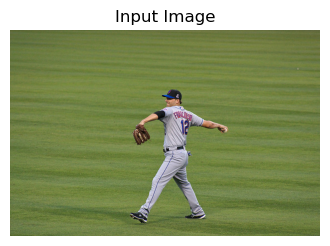

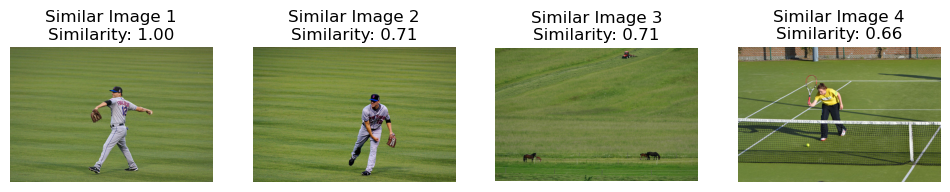

In [63]:
query_image_path = '/Volumes/BigData03/images/coco2017_unlabeled/unlabeled2017/000000001202.jpg'
find_similar_images(query_image_path, image_profiles)

## 3.2 - Cosine similarity with dimensionality reduction

In [ ]:
def calculate_embeddings_batch(image_folder, embedding_dimension, target_size, batch_size):
    # DataFrame für Embedding-Daten erstellen
    columns = ['Image ID', 'File Path', 'Embeddings']
    embedding_data = pd.DataFrame(columns=columns)

    # Anzahl der Bilder ermitteln
    total_images = len(os.listdir(image_folder))
    processed_images = 0

    # Generator für Bilder aus dem Hauptordner in Stapeln
    def image_batch_generator():
        image_batch = []
        for file_name in os.listdir(image_folder):
            if file_name.endswith('.DS_Store'):
                continue

            file_path = os.path.join(image_folder, file_name)
            image = cv2.imread(file_path)
            if image is None:
                print(f"Fehler beim Laden des Bildes: {file_path}")
                continue

            # Bild auf Zielgröße skalieren
            resized_image = cv2.resize(image, target_size)

            # Bild in Graustufen konvertieren
            image_gray = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

            # Bild flach machen
            image_flat = image_gray.flatten()

            image_batch.append((file_name, file_path, image_flat))

            # Wenn Stapelgröße erreicht wurde, den Stapel zurückgeben
            if len(image_batch) == batch_size:
                yield image_batch
                image_batch = []

        # Restlichen Stapel zurückgeben
        if image_batch:
            yield image_batch

    # Bilder schrittweise laden und Embeddings berechnen
    for image_batch in image_batch_generator():
        # Image-IDs, Dateipfade und Embeddings aus dem Stapel extrahieren
        file_names, file_paths, image_flats = zip(*image_batch)

        # Image-IDs, Dateipfade und Embeddings speichern
        new_rows = pd.DataFrame({'Image ID': file_names, 'File Path': file_paths, 'Embeddings': image_flats})
        embedding_data = pd.concat([embedding_data, new_rows], ignore_index=True)

        processed_images += len(image_batch)
        print(f"Verarbeitete Bilder: {processed_images}/{total_images}")

    # DataFrame als CSV speichern
    embedding_data.to_csv('new_embedding_data.csv', index=False)

    # PCA durchführen, um die Dimensionalität der Embeddings zu reduzieren
    pca = PCA(n_components=embedding_dimension)
    embeddings = np.array(embedding_data['Embeddings'].to_list())
    embeddings_pca = pca.fit_transform(embeddings)
    embedding_data['Embeddings'] = [embedding.tolist() for embedding in embeddings_pca]

    # Aktualisierte Embedding-Daten als CSV speichern
    embedding_data.to_csv('new_embedding_data.csv', index=False)

    # PCA-Objekt speichern
    with open('new_pca.pkl', 'wb') as f:
        pickle.dump(pca, f)

    return embedding_data, pca

# Embeddings für alle Bilder berechnen
image_folder = "/Volumes/BigData03/images/coco2017_unlabeled/unlabeled2017"
embedding_dimension = 100  # Gewünschte Dimensionalität für die Embeddings angeben
target_size = (64, 64)  # Gewünschte Zielgröße für die Bilder angeben
batch_size = 100  # Stapelgröße für die Stapelverarbeitung angeben
embedding_data, pca = calculate_embeddings_batch(image_folder, embedding_dimension, target_size, batch_size)

# Embedding-Daten in eine CSV-Datei speichern
embedding_data.to_csv('new_embedding_data.csv', index=False)


Cosine Similarity with Similar Image 1: 0.951141534395063
Cosine Similarity with Similar Image 2: 0.9454138282122746
Cosine Similarity with Similar Image 3: 0.9389809486480358


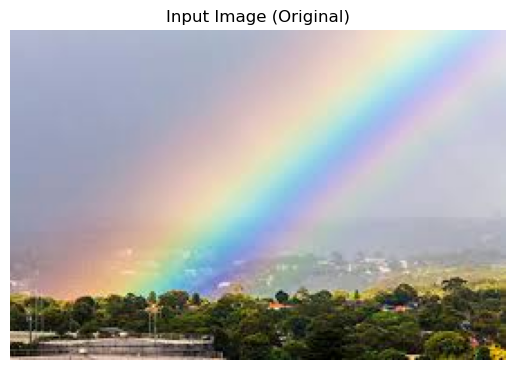

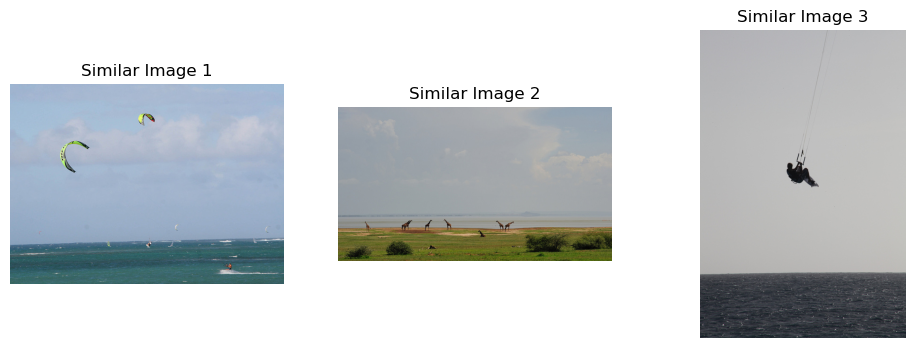

In [83]:
def compare_image(image_path, embedding_data, pca, top_n=3):
   
    input_image = cv2.imread(image_path)
  
    # Resize the input image to the same target size used during embeddings calculation
    target_size = (64, 64)
    input_image = cv2.resize(input_image, target_size)

    
    input_gray = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

    
    input_flat = input_gray.flatten()

    # Transformiere das input image mit dem gespeicherten PCA object
    input_embedding = pca.transform([input_flat])

    # berechne cosine similarity zwischen input Image Embedding und alle anderen Embeddings
    embeddings = np.array([np.array(eval(embedding)) for embedding in embedding_data['Embeddings']])
    similarities = cosine_similarity(input_embedding, embeddings)

    top_indices = np.argsort(similarities.ravel())[-top_n:][::-1]

    #  cosine similarity values für die top N ähnliche Bilder
    top_similarities = similarities[0, top_indices]

    # cosine similarity values ausgeben
    for i in range(top_n):
        print(f"Cosine Similarity with Similar Image {i+1}: {top_similarities[i]}")

    
    top_image_paths = embedding_data.loc[top_indices, 'File Path'].values.tolist()

    
    similar_images = [cv2.imread(file_path) for file_path in top_image_paths]

    
    input_image_original = cv2.imread(image_path)

    # zeige input image
    plt.imshow(cv2.cvtColor(input_image_original, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Input Image (Original)')
    plt.show()

    # zeige ähnliche Bilder
    fig, axs = plt.subplots(1, top_n, figsize=(12, 4))
    for i, image_path in enumerate(top_image_paths):
        similar_image = cv2.imread(image_path)
        axs[i].imshow(cv2.cvtColor(similar_image, cv2.COLOR_BGR2RGB))
        axs[i].axis('off')
        axs[i].set_title(f'Similar Image {i+1}')
    plt.show()

    


# laden von embedding data und PCA object
embedding_data = pd.read_csv('new_embedding_data.csv')
with open('new_pca.pkl', 'rb') as f:
    pca = pickle.load(f)


input_image_path = "/Users/shadobanbouk/Desktop/weather_image_recognition/rainbow/0637.jpg"
compare_image(input_image_path, embedding_data, pca)


## 3.3 - Color Distribution-based Image Similarity Calculation with Dimensionality Reduction

In [4]:
def calculate_color_distribution(image):

    hist = cv2.calcHist([image], [0, 1, 2], None, [8, 8, 8], [0, 256, 0, 256, 0, 256])
    
    hist = cv2.normalize(hist, hist).flatten()
    
    return hist

def calculate_color_distributions(image_folder, save_file=None):
    if save_file and os.path.isfile(save_file):
        color_data = pd.read_csv(save_file)
        return color_data

    # DataFrame for color data
    columns = ['Image ID', 'File Path', 'Color Distribution']
    color_data = pd.DataFrame(columns=columns)


    for file_name in os.listdir(image_folder):
        if file_name.endswith('.DS_Store'):
            continue

        file_path = os.path.join(image_folder, file_name)
        image = cv2.imread(file_path)
        if image is None:
            print(f"Error loading image: {file_path}")
            continue

        
        color_distribution = calculate_color_distribution(image)

        
        color_data = pd.concat([color_data, pd.DataFrame({
            'Image ID': [file_name],
            'File Path': [file_path],
            'Color Distribution': [color_distribution]
        })], ignore_index=True)

    # Convertiere die color distributions zu NumPy arrays
    color_data['Color Distribution'] = color_data['Color Distribution'].apply(lambda x: np.array(x))

   
    if save_file:
        color_data.to_csv(save_file, index=False)

    return color_data

def compare_color_distributions(input_distribution, color_data, top_n=3):

    if len(input_distribution.shape) == 1:
        input_distribution = input_distribution.reshape(1, -1)

    if len(color_data['Color Distribution'].iloc[0].shape) == 1:
        color_data['Color Distribution'] = color_data['Color Distribution'].apply(lambda x: x.reshape(1, -1))

    # berechne cosine similarity zwischen input distribution and alle anderen distributions
    similarities = cosine_similarity(input_distribution, np.vstack(color_data['Color Distribution']))

    
    top_indices = np.argsort(similarities.ravel())[-top_n:][::-1]

    
    top_image_paths = color_data.loc[top_indices, 'File Path'].values.tolist()


    similar_images = [cv2.imread(file_path) for file_path in top_image_paths]

    return similar_images


image_folder = "/Volumes/BigData03/images/coco2017_unlabeled/unlabeled2017"


save_file = "/Users/shadobanbouk/Desktop/color_data_new.csv"

# berechne color distributions für alle images in the main folder and speichere die in eine DataFrame
color_data_new = calculate_color_distributions(image_folder, save_file)


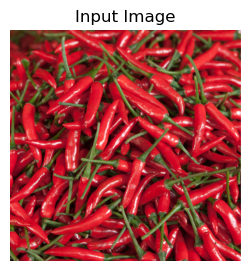

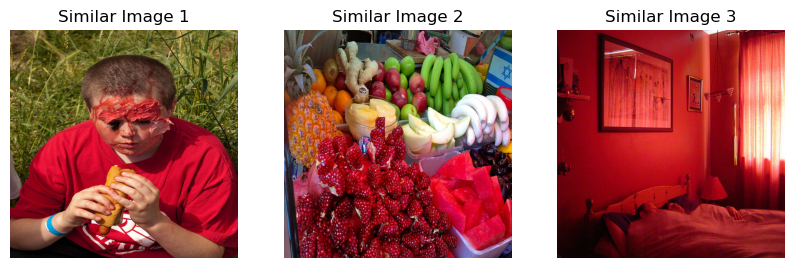

In [84]:

input_image_path = "/Users/shadobanbouk/Desktop/Image_5.png"
input_image = cv2.imread(input_image_path)
input_distribution = calculate_color_distribution(input_image)


top_n = 3


similar_images= compare_color_distributions(input_distribution, color_data_new, top_n)

plt.figure(figsize=(15, 3))  # Anpassung der Figurgröße
plt.imshow(cv2.cvtColor(input_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.show()


fig, axs = plt.subplots(1, top_n, figsize=(10, 5))
for i, image in enumerate(similar_images):
    axs[i].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), extent=[0, 1, 0, 1])  
    axs[i].axis('off')
    axs[i].set_title(f'Similar Image {i+1}')
plt.show()




# Part 2 - Big data image analysis , 2A

In [49]:
# Threshold for similarity
similarity_threshold = 0.8

color_data_path = '/Users/shadobanbouk/Desktop/kopie_color_data_new .csv'

color_data_new_copy = pd.read_csv(color_data_path)


num_images = len(color_data_new_copy)

# Initialize a sparse matrix to store the similarities
similarity_matrix = dok_matrix((num_images, num_images))

for i in tqdm(range(num_images), desc='Computing similarities'):
    current_distribution = np.array(color_data_new_copy['Color Distribution'].iloc[i].strip('[]').split(), dtype=float)

    
    similarities = Parallel(n_jobs=-1)(
        delayed(cosine_similarity)(current_distribution.reshape(1, -1),
                                   np.array(compared_distribution.strip('[]').split(), dtype=float).reshape(1, -1))
        for compared_distribution in color_data_new_copy['Color Distribution'].iloc[i+1:]
    )

    for j, similarity in enumerate(similarities):
        if similarity >= similarity_threshold:
            similarity_matrix[i, i + j + 1] = similarity
            similarity_matrix[i + j + 1, i] = similarity

# Sparse matrix with high similarities
print(similarity_matrix)


Computing similarities:   0%|           | 58/123400 [26:49<950:45:32, 27.75s/it]
Process SpawnPoolWorker-163:
Process SpawnPoolWorker-164:
Process SpawnPoolWorker-157:
Process SpawnPoolWorker-162:
Process SpawnPoolWorker-160:
Process SpawnPoolWorker-166:
Process SpawnPoolWorker-161:
Process SpawnPoolWorker-159:
Process SpawnPoolWorker-165:
Process SpawnPoolWorker-158:
Process SpawnPoolWorker-167:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/multiprocessing/pool.p

KeyboardInterrupt: 

exception calling callback for <Future at 0x7f7a7759d550 state=finished returned list>
Traceback (most recent call last):
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/site-packages/joblib/externals/loky/_base.py", line 625, in _invoke_callbacks
    callback(self)
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/site-packages/joblib/parallel.py", line 360, in __call__
    self.parallel.dispatch_next()
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/site-packages/joblib/parallel.py", line 797, in dispatch_next
    if not self.dispatch_one_batch(self._original_iterator):
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/site-packages/joblib/parallel.py", line 864, in dispatch_one_batch
    self._dispatch(tasks)
  File "/Users/shadobanbouk/opt/anaconda3/envs/big-data/lib/python3.9/site-packages/joblib/parallel.py", line 782, in _dispatch
    job = self._backend.apply_async(batch, callback=cb)
  File "/U

## A graph that connects the most similar images

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


graph = nx.Graph()


for i in range(num_images):
    similar_images = np.where(similarity_matrix[i] >= similarity_threshold)[0]
    # Add edges between the current image and its similar images
    for similar_image in similar_images:
        graph.add_edge(i, similar_image)


pos = nx.spring_layout(graph)  # Choose a layout algorithm
nx.draw(graph, pos, with_labels=False, node_size=10)  # Draw the nodes and edges
plt.show()
